# Parte I – Regresión lineal con una característica


En este cuaderno se modela la luminosidad estelar (L) como una función
lineal de la masa estelar (M), implementando regresión lineal desde
primeros principios sin usar librerías de aprendizaje automático.

Importación de librerías

In [13]:
import numpy as np
import matplotlib.pyplot as plt


Definición del dataset

In [14]:
M = np.array([0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4])
L = np.array([0.15,0.35,1.00,2.30,4.10,7.00,11.2,17.5,25.0,35.0])


### 1. Visualización del conjunto de datos M vs L

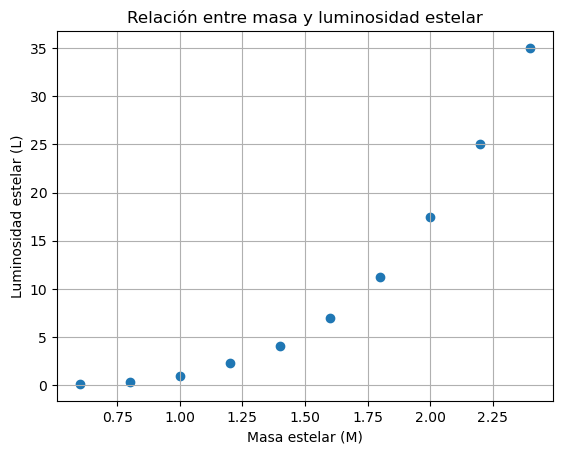

In [15]:
plt.scatter(M, L)
plt.xlabel("Masa estelar (M)")
plt.ylabel("Luminosidad estelar (L)")
plt.title("Relación entre masa y luminosidad estelar")
plt.grid(True)
plt.show()

La relación entre la masa y la luminosidad no es perfectamente lineal.
Se observa un crecimiento acelerado, lo que sugiere que un modelo lineal
es una aproximación limitada pero útil como primer modelo.


### 2. Modelo:
$$
\hat{L} = w @ M + b
$$

Donde:

M = masa estelar (dato que conocemos)

L = luminosidad real (dato observado)

$\hat{L}$: luminosidad predicha por el modelo

w = cuánto cambia L cuando M aumenta 1 unidad

b = luminosidad base cuando M = 0 (sesgo)

In [16]:
def predict(M, w, b):
    return w * M + b

### 2.1. Función de pérdida(MSE)

$$
J(w, b) = \frac{1}{n} \sum (L - \hat{L})^2
$$

In [17]:
def mse(y_true, y_pred):
    error = y_true - y_pred
    return np.mean(error ** 2)

### 3. Superficie de costo

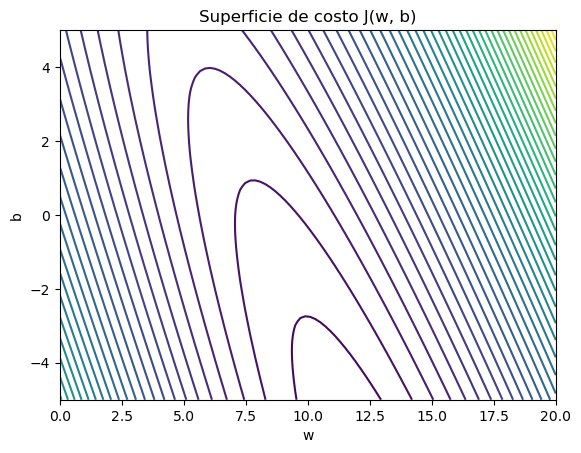

In [18]:
w_values = np.linspace(0, 20, 100)
b_values = np.linspace(-5, 5, 100)

W, B = np.meshgrid(w_values, b_values)
J = np.zeros(W.shape)

#Evaluar el costo en cada punto
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L_hat = predict(M, W[i, j], B[i, j])
        J[i, j] = mse(L, L_hat)

#Gráfico de contorno 
plt.contour(W, B, J, levels=50)
plt.xlabel("w")
plt.ylabel("b")
plt.title("Superficie de costo J(w, b)")
plt.show()

El mínimo de la superficie de costo representa la combinación de parámetros
(w, b) que produce el menor error cuadrático medio, es decir, el mejor ajuste
lineal posible para los datos.


### 4. Gradientes

Las derivadas del MSE respecto a los parámetros son:

$$
\frac{\partial J}{\partial w} = -\frac{2}{n} \sum M_i \left( L_i - \hat{y}_i \right)
$$

$$
\frac{\partial J}{\partial b} = -\frac{2}{n} \sum \left( L_i - \hat{y}_i \right)
$$


### 5. Descenso de gradiente (no vectorizado)

In [19]:
def gradient_descent_loop(M, L, w, b, alpha, epochs):
    n = len(M)
    loss_history = []

    for _ in range(epochs):
        dw = 0
        db = 0

        for i in range(n):
            y_hat = w * M[i] + b
            error = L[i] - y_hat
            dw += -2 * M[i] * error
            db += -2 * error

        dw /= n
        db /= n

        w -= alpha * dw
        b -= alpha * db

        loss_history.append(mse(L, predict(M, w, b)))

    return w, b, loss_history


### 6. Descenso de gradiente (vectorizado)

In [20]:
def gradient_descent_vectorized(M, L, w, b, alpha, epochs):
    n = len(M)
    loss_history = []

    for _ in range(epochs):
        y_hat = predict(M, w, b)
        error = L - y_hat

        dw = (-2/n) * np.sum(M * error)
        db = (-2/n) * np.sum(error)

        w -= alpha * dw
        b -= alpha * db

        loss_history.append(mse(L, y_hat))

    return w, b, loss_history


### 7. Convergencia

In [21]:
w, b, loss_history = gradient_descent_vectorized(
    M, L,
    w=0,
    b=0,
    alpha=0.01,
    epochs=1000
)

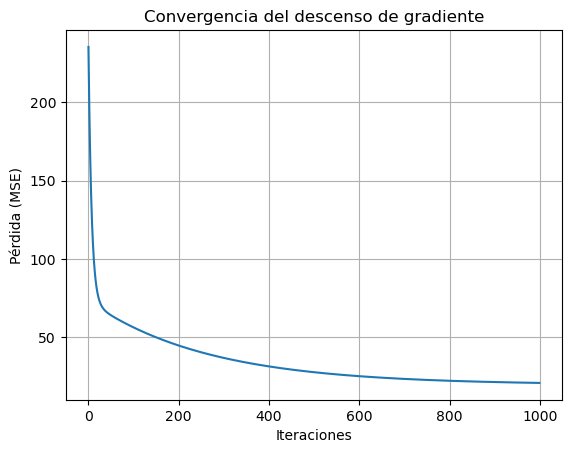

In [22]:
plt.plot(loss_history)
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida (MSE)")
plt.title("Convergencia del descenso de gradiente")
plt.grid(True)
plt.show()

La pérdida disminuye progresivamente a lo largo de las iteraciones,
lo que indica que el algoritmo de descenso de gradiente converge hacia
un mínimo de la función de costo. La estabilidad y la velocidad de
convergencia dependen de la tasa de aprendizaje utilizada.



### 8. Experimentos 

In [23]:
for alpha in [0.001, 0.01, 0.05]:
    w, b, _ = gradient_descent_vectorized(M, L, 0, 0, alpha, 1000)
    print(f"alpha={alpha} → w={w:.2f}, b={b:.2f}, loss={mse(L, predict(M,w,b)):.2f}")

alpha=0.001 → w=7.96, b=0.01, loss=56.26
alpha=0.01 → w=16.28, b=-13.78, loss=20.80
alpha=0.05 → w=18.13, b=-16.83, loss=19.59


### 9. Gráfica final y análisis

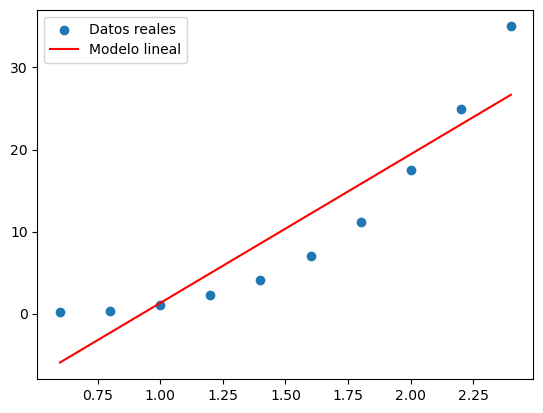

In [24]:
plt.scatter(M, L, label="Datos reales")
plt.plot(M, predict(M, w, b), color="red", label="Modelo lineal")
plt.legend()
plt.show()

El modelo subestima la luminosidad para masas altas, lo que indica un sesgo debido a la naturaleza no lineal del fenómeno físico.


### 10. Preguntas conceptuales

#### Significado astrofísico de w
El parámetro w representa la tasa promedio de incremento de la luminosidad
por unidad de masa estelar.

#### ¿Por qué un modelo lineal está limitado?
Porque la relación real entre masa y luminosidad en la secuencia principal
es no lineal y crece más rápido que una función lineal.
